In [ ]:
from __future__ import annotations

import matplotlib.pyplot as plt
from pyprojroot import here
import datetime as dt
import numpy as np
import pandas as pd
from scipy import stats

In [ ]:
ROOT = here()
DATA_DIR = ROOT / "1_data" /  "raw" / "price_data"
SAVE_DIR = ROOT / "1_data" / "processed"

## Load data

In [ ]:
gb_da = pd.read_csv(DATA_DIR / "GB_DA.csv")
gb_da.rename(columns={"Datetime (UTC)": 'datetime', "Price (GBP/MWh)": 'da'}, inplace=True)
gb_da['datetime'] = pd.to_datetime(gb_da['datetime'], dayfirst=True, utc=True)

gb_imb_raw = pd.read_csv(DATA_DIR / "elexon_sp_data_2016_2020.csv")

## 1. Align DA and imbalance prices, Check data quality
Timing:
- Left joined both DA and IMB price data to time index df, to ensure completeness of data
- Aligned to UTC +0 time

Day-ahead prices:
- No missing values

Imbalance prices:
- Only missing values in period of interest for dissertation is hourly period of 2018-12-12 18:00:00+00:00

Create gb_price_final

In [ ]:
assert((gb_imb_raw["SystemSellPrice"] - gb_imb_raw["SystemBuyPrice"] == 0).all())
gb_hh_imb = gb_imb_raw[["SettlementDate", "SettlementPeriod", "SystemSellPrice"]].copy()
gb_hh_imb[gb_hh_imb.isna().any(axis=1)]   # check for any rows with NaN values

,SettlementDate,SettlementPeriod,SystemSellPrice


In [ ]:
print(gb_da[gb_da.isna().any(axis=1)])   # check for any rows with NaN values

# Check that gb_da timestamps are timezone-aware and UTC-aligned
assert gb_da["datetime"].dt.tz is not None, "gb_da['datetime'] is not timezone-aware"
assert str(gb_da["datetime"].dt.tz) == "UTC", "gb_da['datetime'] is not UTC"

# Confirm the series is sorted and hourly
assert gb_da["datetime"].is_monotonic_increasing, "gb_da['datetime'] is not sorted"
assert (gb_da["datetime"].dt.minute == 0).all(), "gb_da timestamps are not all on the hour"

Empty DataFrame
Columns: [datetime, da]
Index: []


## Align Imb price data to UTC+0

In [ ]:
# df has columns: 'SettlementDate' (date), 'SettlementPeriod' (1..50)

# 1. Local midnight of the settlement date, made tz-aware, then to UTC.
#    Midnight is always unambiguous in Europe/London, so localize is safe here.
local_midnight = (
    pd.to_datetime(gb_hh_imb['SettlementDate'])
      .dt.tz_localize('Europe/London')   # unambiguous at 00:00
      .dt.tz_convert('UTC')
)

# 2. Add (period-1) half-hours as a fixed UTC timedelta.
#    Because we're now in UTC, arithmetic is clean and DST-safe:
#    the spring/autumn hour change is already baked into local_midnight's
#    UTC value, so period offsets just accumulate correctly.
utc_start = local_midnight + pd.to_timedelta((gb_hh_imb['SettlementPeriod'] - 1) * 30, unit='min')

gb_hh_imb['utc_start'] = utc_start   # UTC start time of each settlement period

gb_hh_imb['utc_hour'] = gb_hh_imb['utc_start'].dt.floor('h')
hourly_imb = gb_hh_imb.groupby('utc_hour')['SystemSellPrice'].mean()   # two SPs per hour -> hourly mean

hourly_imb = hourly_imb.reset_index().rename(columns={'utc_hour': 'datetime', 'SystemSellPrice': 'imb'})
hourly_imb[hourly_imb.isna().any(axis=1)]   # check for any rows with NaN values

,datetime,imb


In [ ]:
hourly_utc_index = pd.date_range(
    start=gb_da["datetime"].min(),
    end=gb_da["datetime"].max(),
    freq="h",
    tz="UTC",
)

In [ ]:
gb_price = hourly_utc_index.to_frame(index=False, name='datetime').merge(gb_da, on='datetime', how='left').merge(hourly_imb, on='datetime', how='left')

In [ ]:
gb_price[gb_price.isna().any(axis=1)]   # check for any rows with NaN values

,datetime,da,imb
7703,2017-10-17 23:00:00+00:00,37.941835,NaN
7704,2017-10-18 00:00:00+00:00,37.806300,NaN
7705,2017-10-18 01:00:00+00:00,37.806300,NaN
7706,2017-10-18 02:00:00+00:00,34.039950,NaN
7707,2017-10-18 03:00:00+00:00,33.004650,NaN
7708,2017-10-18 04:00:00+00:00,43.295175,NaN
7709,2017-10-18 05:00:00+00:00,57.298500,NaN
7710,2017-10-18 06:00:00+00:00,60.716775,NaN
7711,2017-10-18 07:00:00+00:00,58.958550,NaN
7712,2017-10-18 08:00:00+00:00,56.468475,NaN


In [ ]:
## Note: only 1 row within the train eval test period (Dec 2017 to mid 2020) has a NaN value, so we can interpolate it. The other NaN values are outside the train eval test period, so we can ignore them.
gb_price["imb"] = gb_price["imb"].interpolate(method="linear", limit_direction="both")
gb_price.set_index("datetime", inplace=True)
gb_price_final = gb_price.loc['2017-11-01':'2022-08-01'].copy()  # only keep the period of interest for the dissertation

In [ ]:
gb_price_final[gb_price_final.isna().any(axis=1)]   # check for any rows with NaN values
# all gone!

,da,imb
datetime,,


## 2. Create dual-price price columns, analyse data.

for datetime in price:

if imb > da:
- system is short. wants people to sell more power (make imb more expensive than da). 
- This is as system doesn't want to overly incentivise people to buy power.
- imb_up = imb
- imb_down = da

if imb < da:
- system is long. Wants people to buy more power (make imb cheaper than da).
- System wants to incentivise people to buy power
- imb_up = da
- imb_down = imb

if imb = da:
- system is balanced. imb should be day-ahead price
- imb_up = imb_down = da

In [ ]:
da = gb_price_final["da"]
imb_up = np.maximum(gb_price_final["da"], gb_price_final["imb"])
imb_down = np.minimum(gb_price_final["da"], gb_price_final["imb"])

#up_reg_cost = (imb_up - da).clip(lower=0)
#down_reg_cost = (da - imb_down).clip(lower=0)

##save to dataset
#gb_price_final["up_reg_cost"] = up_reg_cost
#gb_price_final["down_reg_cost"] = down_reg_cost
gb_price_final["imb_up"] = imb_up
gb_price_final["imb_down"] = imb_down

In [ ]:
gb_price_final.to_csv(SAVE_DIR / "gb_price.csv", index=True)

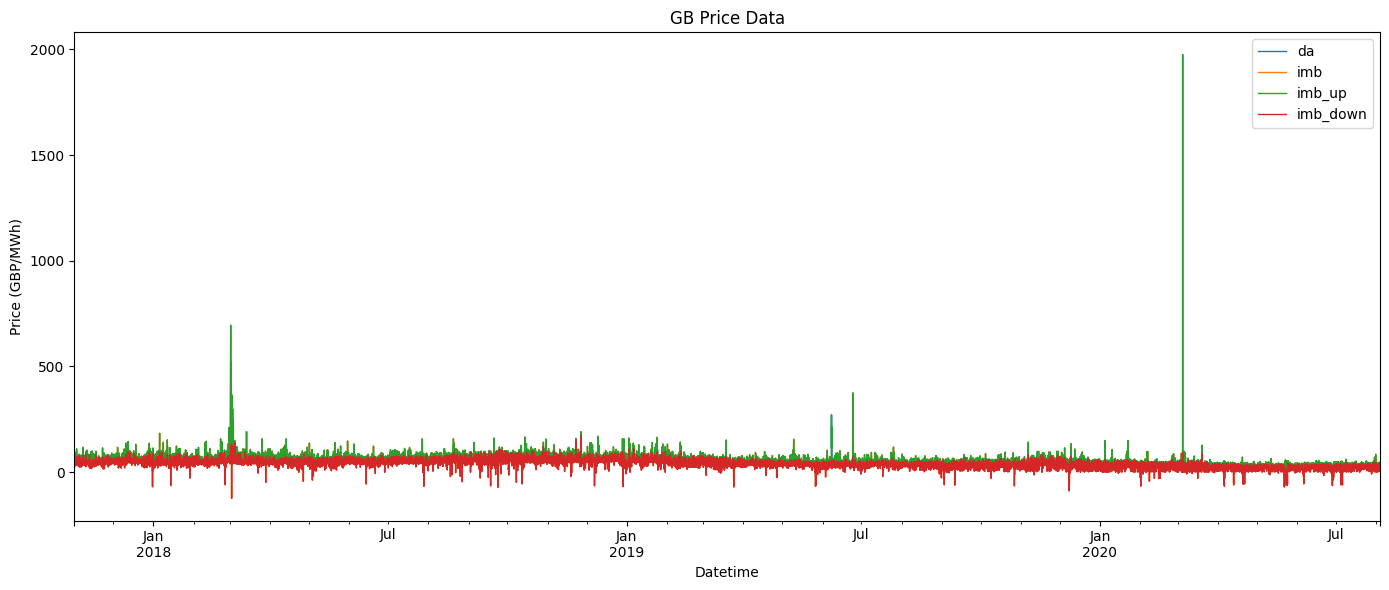

In [ ]:
#time_start = '2017-11-01'
#time_end = '2017-12-31'
#.loc[time_start:time_end]

fig, ax = plt.subplots(figsize=(14, 6))
gb_price_final.plot(ax=ax, linewidth=1)
ax.set_xlabel('Datetime')
ax.set_ylabel('Price (GBP/MWh)')
ax.set_title(f'GB Price Data')
#ax.set_title(f'GB Price Data ({time_start} to {time_end})')
ax.legend(loc='best')
plt.tight_layout()
plt.show()

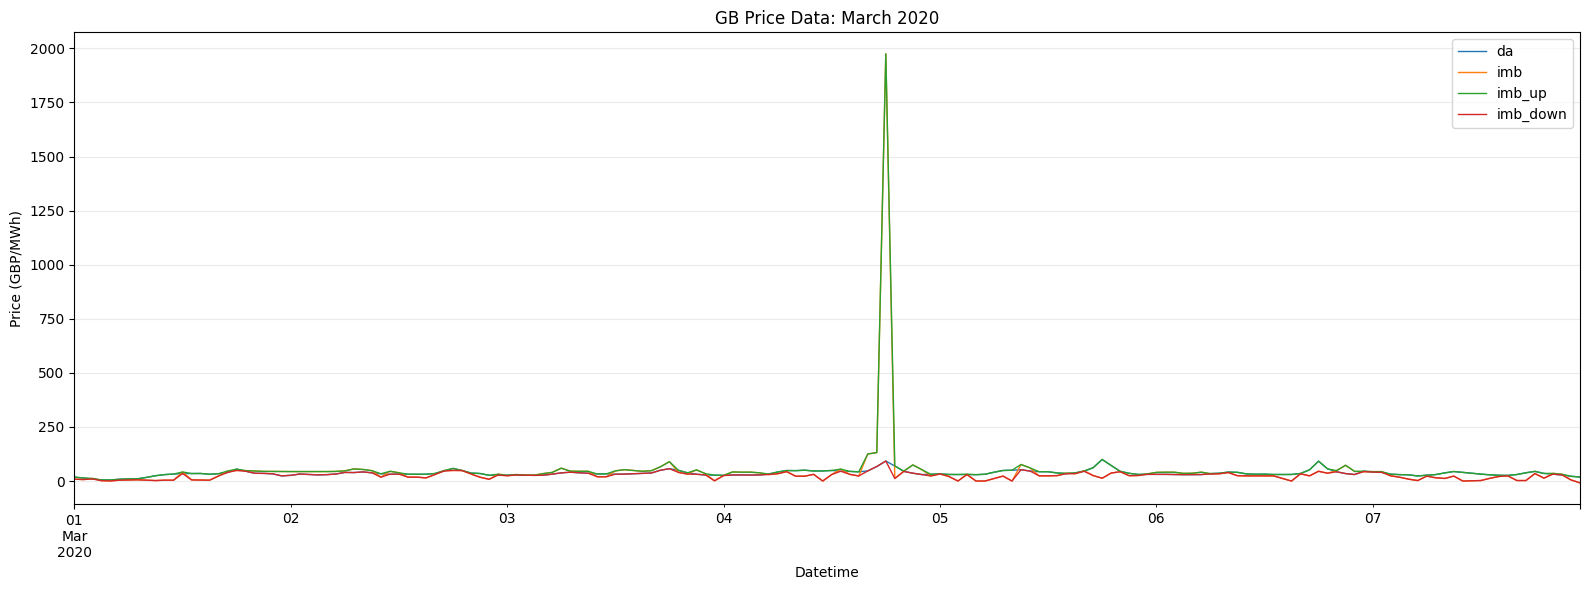

In [ ]:
month_start = pd.Timestamp("2020-03-01 00:00:00", tz="UTC")
month_end = pd.Timestamp("2020-03-07 23:00:00", tz="UTC")

march_2020 = gb_price_final.loc[month_start:month_end]

fig, ax = plt.subplots(figsize=(16, 6))
march_2020[["da", "imb", "imb_up", "imb_down"]].plot(ax=ax, linewidth=1)
ax.set_xlabel("Datetime")
ax.set_ylabel("Price (GBP/MWh)")
ax.set_title("GB Price Data: March 2020")
ax.legend(loc="best")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

In [ ]:
# Replace all hourly imbalance prices on 2020-03-04 with the corresponding values from 2020-03-03
source_day = pd.Timestamp("2020-03-03 00:00:00", tz="UTC")
target_day = pd.Timestamp("2020-03-04 00:00:00", tz="UTC")

source_idx = pd.date_range(start=source_day, end=source_day + pd.Timedelta(days=1) - pd.Timedelta(hours=1), freq="h")
target_idx = pd.date_range(start=target_day, end=target_day + pd.Timedelta(days=1) - pd.Timedelta(hours=1), freq="h")

source_vals = gb_price_final.loc[source_idx, "imb"].to_numpy()
gb_price_final.loc[target_idx, "imb"] = source_vals

# Recompute the dual-price columns consistent with the replaced imbalance values
gb_price_final["imb_up"] = np.maximum(gb_price_final["da"], gb_price_final["imb"])
gb_price_final["imb_down"] = np.minimum(gb_price_final["da"], gb_price_final["imb"])

gb_price_final.loc[target_idx, ["imb", "imb_up", "imb_down"]]

,imb,imb_up,imb_down
2020-03-04 00:00:00+00:00,24.34500,26.301609,24.345000
2020-03-04 01:00:00+00:00,30.03500,30.035000,28.022760
2020-03-04 02:00:00+00:00,27.13500,28.126548,27.135000
2020-03-04 03:00:00+00:00,27.16500,27.607608,27.165000
2020-03-04 04:00:00+00:00,34.38000,34.380000,28.169793
2020-03-04 05:00:00+00:00,39.85000,39.850000,32.295366
2020-03-04 06:00:00+00:00,59.45000,59.450000,41.748723
2020-03-04 07:00:00+00:00,45.75000,48.581433,45.750000
2020-03-04 08:00:00+00:00,45.00000,48.053844,45.000000
2020-03-04 09:00:00+00:00,44.99500,50.060412,44.995000


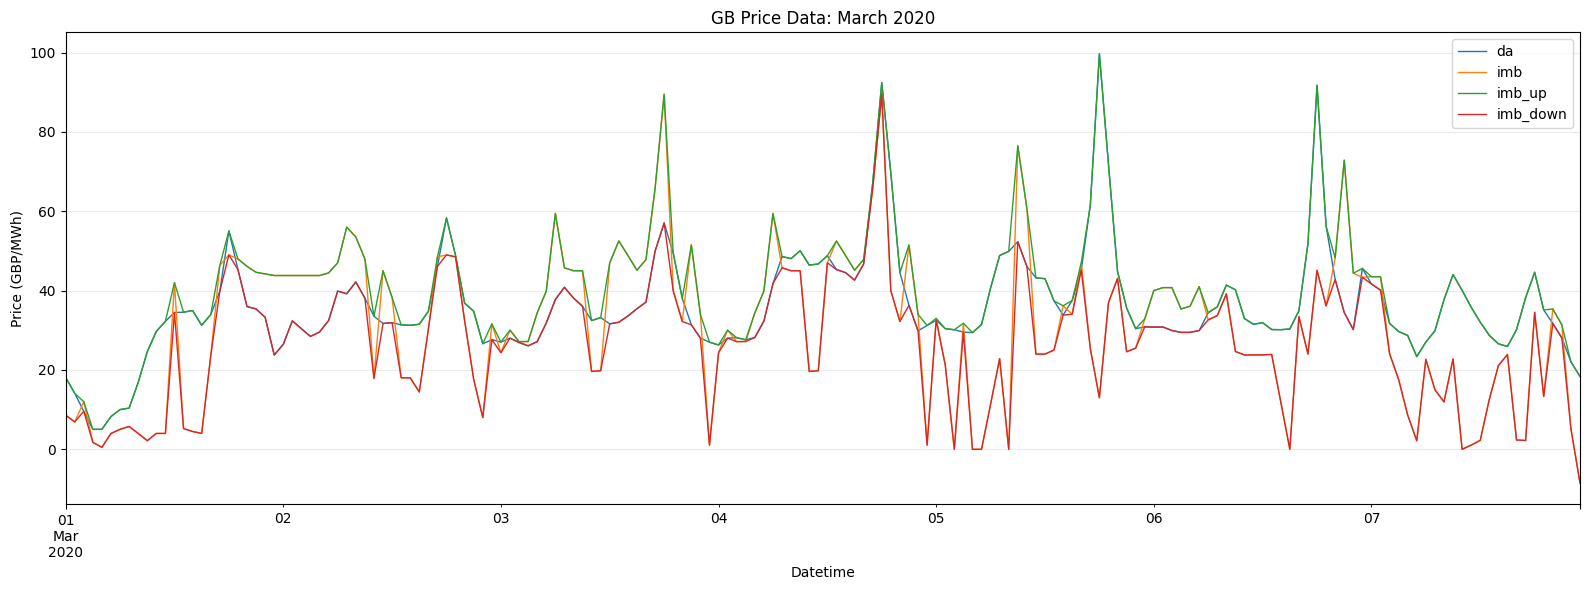

In [ ]:
month_start = pd.Timestamp("2020-03-01 00:00:00", tz="UTC")
month_end = pd.Timestamp("2020-03-07 23:00:00", tz="UTC")

march_2020 = gb_price_final.loc[month_start:month_end]

fig, ax = plt.subplots(figsize=(16, 6))
march_2020[["da", "imb", "imb_up", "imb_down"]].plot(ax=ax, linewidth=1)
ax.set_xlabel("Datetime")
ax.set_ylabel("Price (GBP/MWh)")
ax.set_title("GB Price Data: March 2020")
ax.legend(loc="best")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

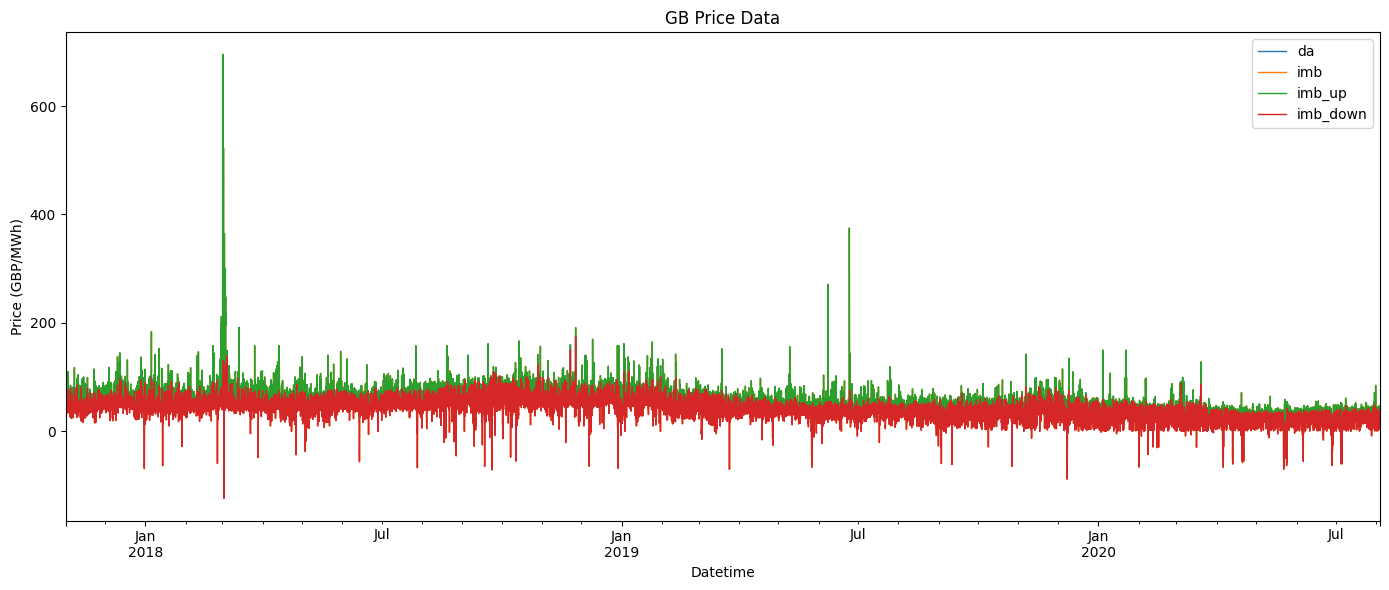

In [ ]:
#time_start = '2017-11-01'
#time_end = '2017-12-31'
#.loc[time_start:time_end]

fig, ax = plt.subplots(figsize=(14, 6))
gb_price_final.plot(ax=ax, linewidth=1)
ax.set_xlabel('Datetime')
ax.set_ylabel('Price (GBP/MWh)')
ax.set_title(f'GB Price Data')
#ax.set_title(f'GB Price Data ({time_start} to {time_end})')
ax.legend(loc='best')
plt.tight_layout()
plt.show()

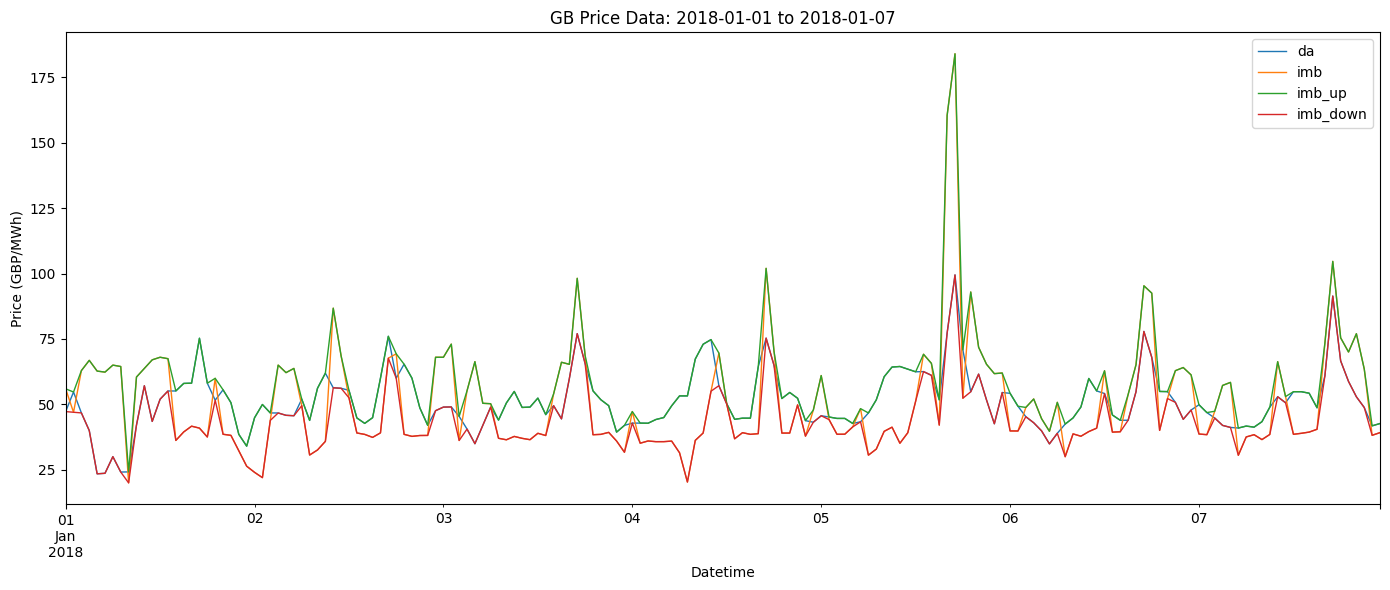

In [ ]:
# Plot one week of GB price data from January 2018
week_start = pd.Timestamp("2018-01-01 00:00:00", tz="UTC")
week_end = pd.Timestamp("2018-01-07 23:00:00", tz="UTC")

jan_week = gb_price_final.loc[week_start:week_end]

fig, ax = plt.subplots(figsize=(14, 6))
#jan_week[["da", "imb", "up_reg_cost", "down_reg_cost"]].plot(ax=ax, linewidth=1)
jan_week[["da", "imb", "imb_up", "imb_down"]].plot(ax=ax, linewidth=1)
ax.set_xlabel("Datetime")
ax.set_ylabel("Price (GBP/MWh)")
ax.set_title(f"GB Price Data: {week_start.date()} to {week_end.date()}")
ax.legend(loc="best")
plt.tight_layout()
plt.show()

In [ ]:
gb_price_final

,da,imb,imb_up,imb_down
datetime,,,,
2017-11-01 00:00:00+00:00,43.590699,44.500,44.500000,43.590699
2017-11-01 01:00:00+00:00,40.188327,43.220,43.220000,40.188327
2017-11-01 02:00:00+00:00,32.936364,33.050,33.050000,32.936364
2017-11-01 03:00:00+00:00,30.419661,36.645,36.645000,30.419661
2017-11-01 04:00:00+00:00,29.937366,25.545,29.937366,25.545000
...,...,...,...,...
2020-08-03 19:00:00+00:00,38.494320,47.000,47.000000,38.494320
2020-08-03 20:00:00+00:00,37.738824,39.310,39.310000,37.738824
2020-08-03 21:00:00+00:00,32.261478,15.125,32.261478,15.125000


## Price uncertainty proxy (exploratory)

In this dissertation, I won't be forecasting imb. Building a dedicated
forecaster would need its own pre-training history to avoid leaking into the DFL train/val/test
split. Also, more work than I've already done (a fucking lot). Instead, price uncertainty is represented as a causally-valid stochastic proxy.

- **Window length**: the autocorrelation of `|da-imb|` carries real signal out to ~24h (with a
  diurnal echo bump at the 24h lag itself), then flattens into noise by ~48-72h -- so a 24h
  trailing window is used.
- **Lead time / no leakage**: decisions are issued `LEAD_HOURS` before a `WINDOW_HOURS`-long
  delivery window and are not updated once issued (gate-aligned). So `sigma_proxy` attached to a
  given window must be frozen using only data available at *issue time*, not window start --
  requiring an explicit forward shift by `LEAD_HOURS` once aligned to the window's own
  timestamps, on top of the rolling window itself only ever looking backward.

This is explicitly a proxy, not a forecast -- by the far end of a 24h window, the sigma it was
given is already describing volatility from roughly a day and a half earlier.

Going to try out different ways of representing this.

First try:

`imb_hat = da + N(0, sigma_proxy)`

where `sigma_proxy` tracks recent realised `|da - imb|` volatility via a trailing rolling std,
rather than being an arbitrary noise scale. Two structural constraints, both established above:

Second try:
- Instead of using gaussian dist, use student t distribution, as the fat tails fit imbalance price spread much better.

In [ ]:
spread_abs = (gb_price_final["da"] - gb_price_final["imb"]).abs()

In [ ]:
spread_abs

datetime
2017-11-01 00:00:00+00:00     0.909301
2017-11-01 01:00:00+00:00     3.031673
2017-11-01 02:00:00+00:00     0.113636
2017-11-01 03:00:00+00:00     6.225339
2017-11-01 04:00:00+00:00     4.392366
                               ...    
2020-08-03 19:00:00+00:00     8.505680
2020-08-03 20:00:00+00:00     1.571176
2020-08-03 21:00:00+00:00    17.136478
2020-08-03 22:00:00+00:00     2.460500
2020-08-03 23:00:00+00:00     0.930238
Length: 24168, dtype: float64

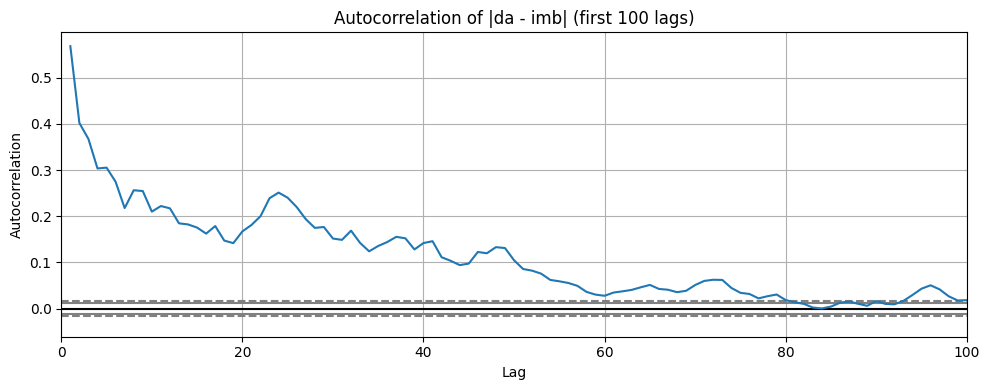

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))
pd.plotting.autocorrelation_plot(spread_abs, ax=ax)
ax.set_xlim(0, 100)
ax.set_title("Autocorrelation of |da - imb| (first 100 lags)")
plt.tight_layout()
plt.show()

In [ ]:
LEAD_HOURS = 9     # decisions issued this many hours before the delivery window starts
WINDOW_HOURS = 24  # length of the delivery window
ROLL_HOURS = 24     # trailing window used to estimate current |da-imb| volatility

# std of |da-imb| over a trailing ROLL_HOURS window, using only data up to and
# including t (pandas rolling is trailing + inclusive of the current row by default)
day_rolling_sigma = spread_abs.rolling(ROLL_HOURS, min_periods=ROLL_HOURS).std()

## Shift the rolling sigma by 24 - LEAD_hours (15 hours), so that the rolling average at 9am
# is used for the midnight time-period.
aligned_day_rolling_sigma = day_rolling_sigma.shift(24 - LEAD_HOURS)

## Mask this so only the midnight values remain (representing rolling sigma at 9am the day before) 
issue_hour_mask = aligned_day_rolling_sigma.index.hour == 0
rolling_sigma_at_issue = aligned_day_rolling_sigma.where(issue_hour_mask)

## Forward-fill the midnight values to the next 23 hours
gb_price_final["imb_sigma_proxy"] = rolling_sigma_at_issue.ffill(limit=WINDOW_HOURS - 1)

print(gb_price_final[["da", "imb", "imb_sigma_proxy"]].tail(36))

                                  da        imb  imb_sigma_proxy
datetime                                                        
2020-08-02 12:00:00+00:00  24.333296  22.420000        14.685304
2020-08-02 13:00:00+00:00  22.245528   5.270000        14.685304
2020-08-02 14:00:00+00:00  21.966559  15.785000        14.685304
2020-08-02 15:00:00+00:00  24.477280  31.000000        14.685304
2020-08-02 16:00:00+00:00  29.975669  42.875000        14.685304
2020-08-02 17:00:00+00:00  34.979113  45.750000        14.685304
2020-08-02 18:00:00+00:00  35.978002  37.915000        14.685304
2020-08-02 19:00:00+00:00  36.841906  32.520000        14.685304
2020-08-02 20:00:00+00:00  39.676591  41.625000        14.685304
2020-08-02 21:00:00+00:00  32.315409  16.210000        14.685304
2020-08-02 22:00:00+00:00  25.836129   9.525000        14.685304
2020-08-02 23:00:00+00:00  24.225308  33.330000        14.685304
2020-08-03 00:00:00+00:00  23.969010  22.400000         7.875049
2020-08-03 01:00:00+00:00

## Try fitting some distributions on the training data for Imbalance
- Normal Dist.
- Standard t.

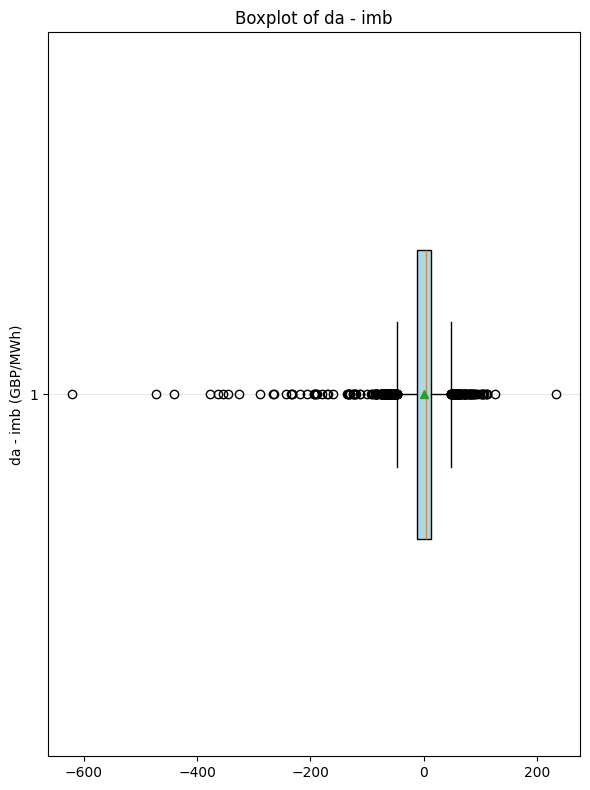

In [ ]:
DFL_TRAIN_START = pd.Timestamp("2018-01-01 00:00:00", tz="UTC")
DFL_VAL_START = pd.Timestamp("2019-01-01 00:00:00", tz="UTC")
spread = gb_price_final["da"] - gb_price_final["imb"]
spread_train = spread.loc[DFL_TRAIN_START:DFL_VAL_START - pd.Timedelta(hours = 1)]


# Box plot for spread (da - imb). Uses trimmed `spread_clip` if available, otherwise full `spread`.

fig, ax = plt.subplots(figsize=(6, 8))
ax.boxplot(spread_train, orientation = "horizontal", widths=0.4, showmeans=True, patch_artist=True,
           boxprops=dict(facecolor="lightblue"))
ax.set_ylabel("da - imb (GBP/MWh)")
ax.set_title("Boxplot of da - imb")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

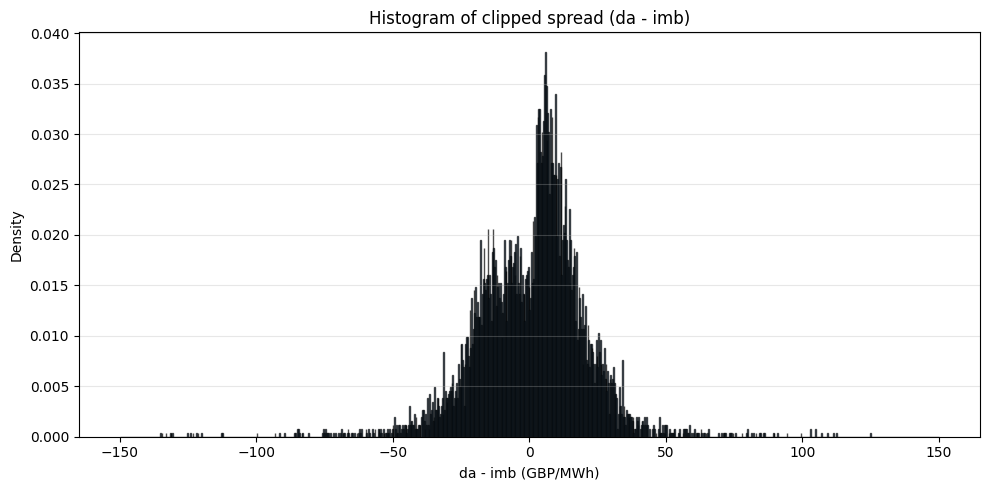

In [ ]:
from scipy import stats


width = 150

lower, upper = -width, width

# Clip/cut the spread into the visualisation/fitting window before fitting
spread_clip = spread_train[(spread >= lower) & (spread <= upper)].dropna()

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(spread_clip.dropna(), bins=1000, range=(lower, upper), density=True, color="steelblue", edgecolor="black", alpha=0.7)
ax.set_xlabel("da - imb (GBP/MWh)")
ax.set_ylabel("Density")
ax.set_title("Histogram of clipped spread (da - imb)")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

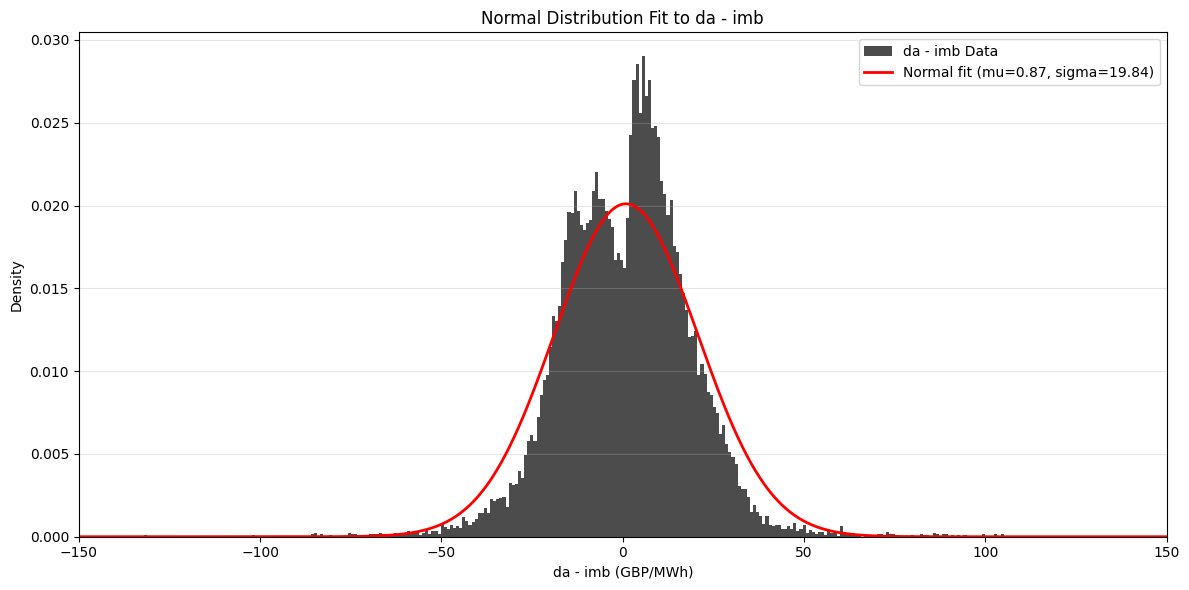

Fitted normal distribution: mean=0.868, std=19.844


In [ ]:
mu, sigma = stats.norm.fit(spread_clip)

x_axis = np.linspace(lower, upper, 1000)
pdf_norm = stats.norm.pdf(x_axis, mu, sigma)

fig, ax = plt.subplots(figsize=(12, 6))
ax.hist(spread, bins=1000, density=True, color="black", alpha=0.7, label="da - imb Data")
ax.plot(x_axis, pdf_norm, "r-", linewidth=2, label=f"Normal fit (mu={mu:.2f}, sigma={sigma:.2f})")

ax.set_xlim(lower, upper)
ax.set_xlabel("da - imb (GBP/MWh)")
ax.set_ylabel("Density")
ax.set_title("Normal Distribution Fit to da - imb")
ax.legend(loc="best")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Fitted normal distribution: mean={mu:.3f}, std={sigma:.3f}")

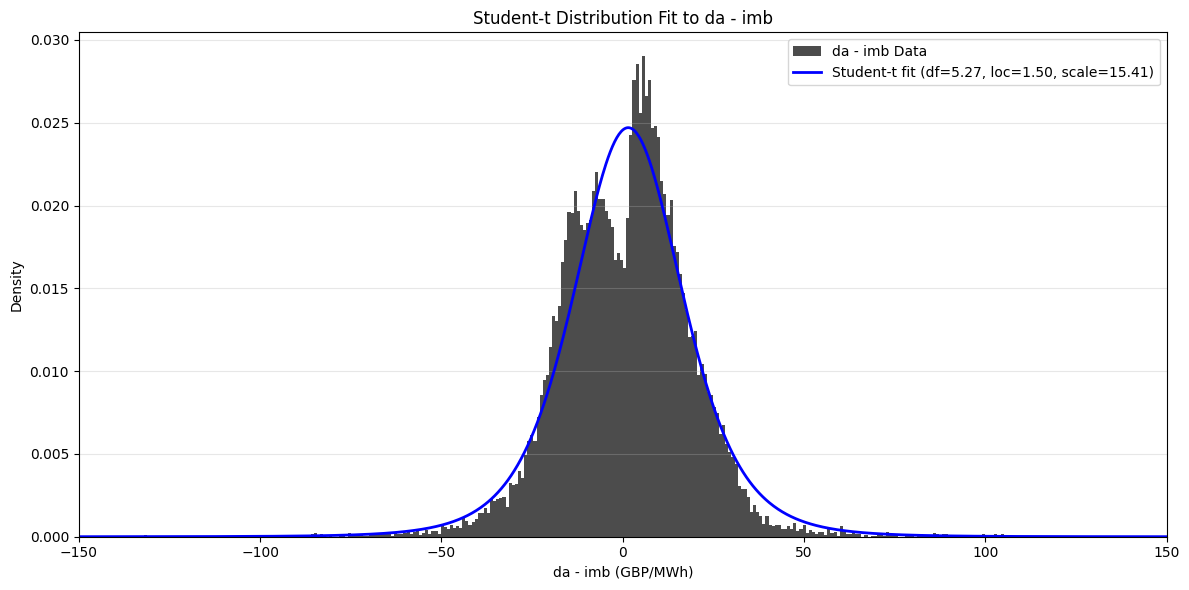

Fitted Student-t params: df=5.267, loc=1.496, scale=15.407


In [ ]:
t_dof, t_loc, t_scale = stats.t.fit(spread_clip)

x_axis = np.linspace(-150, 150, 1000)
pdf_t = stats.t.pdf(x_axis, df=t_dof, loc=t_loc, scale=t_scale)

fig, ax = plt.subplots(figsize=(12, 6))
ax.hist(spread, bins=1000, density=True, color="black", alpha=0.7, label="da - imb Data")
ax.plot(x_axis, pdf_t, "b-", linewidth=2, label=f"Student-t fit (df={t_dof:.2f}, loc={t_loc:.2f}, scale={t_scale:.2f})")

ax.set_xlim(-150, 150)
ax.set_xlabel("Day-ahead - imbalance price spread (GBP/MWh)")
ax.set_ylabel("Density")
ax.set_title("Student-t distribution fit to Day-ahead - imbalance price spread (clipped outliers beyond +- 150)")
ax.legend(loc="best")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Fitted Student-t params: df={t_dof:.3f}, loc={t_loc:.3f}, scale={t_scale:.3f}")

## Results:
- Neither perfect, but T-dist better fit.
- Now, test both options against a test week, scaling each distribution by the rolling sigma proxy.

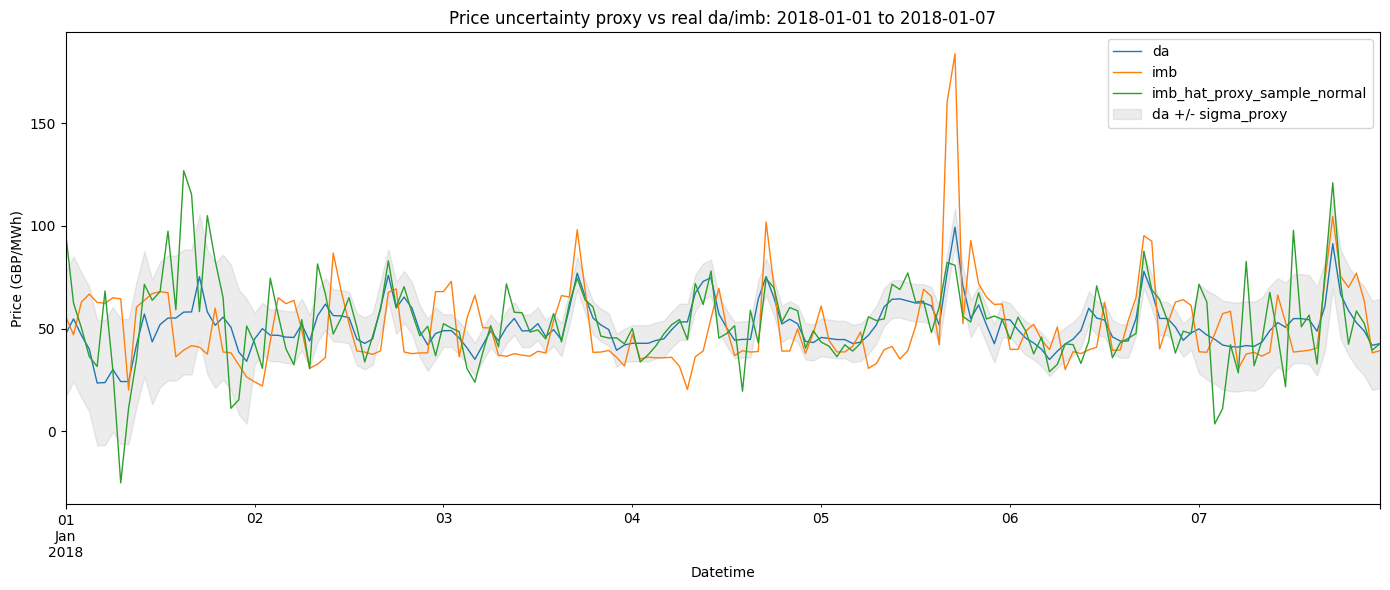

In [ ]:
## NORMAL DISTRIBUTION

# Demonstration: sample imb_hat = da + N(0, sigma_proxy) for the same January 2018
# week plotted earlier, and compare against the real da/imb series.
rng = np.random.default_rng(20240801)
noise_sample = rng.normal(loc=0.0, scale=gb_price_final["imb_sigma_proxy"].to_numpy())
gb_price_final["imb_hat_proxy_sample_normal"] = gb_price_final["da"] + noise_sample

jan_week_proxy = gb_price_final.loc[week_start:week_end]

fig, ax = plt.subplots(figsize=(14, 6))
jan_week_proxy[["da", "imb", "imb_hat_proxy_sample_normal"]].plot(ax=ax, linewidth=1)
ax.fill_between(
    jan_week_proxy.index,
    jan_week_proxy["da"] - jan_week_proxy["imb_sigma_proxy"],
    jan_week_proxy["da"] + jan_week_proxy["imb_sigma_proxy"],
    alpha=0.15, color="gray", label="da +/- sigma_proxy",
)
ax.set_xlabel("Datetime")
ax.set_ylabel("Price (GBP/MWh)")
ax.set_title(f"Price uncertainty proxy vs real da/imb: {week_start.date()} to {week_end.date()}")
ax.legend(loc="best")
plt.tight_layout()
plt.show()

fitted Student-t params: df=5.267, loc=1.496, scale=15.407


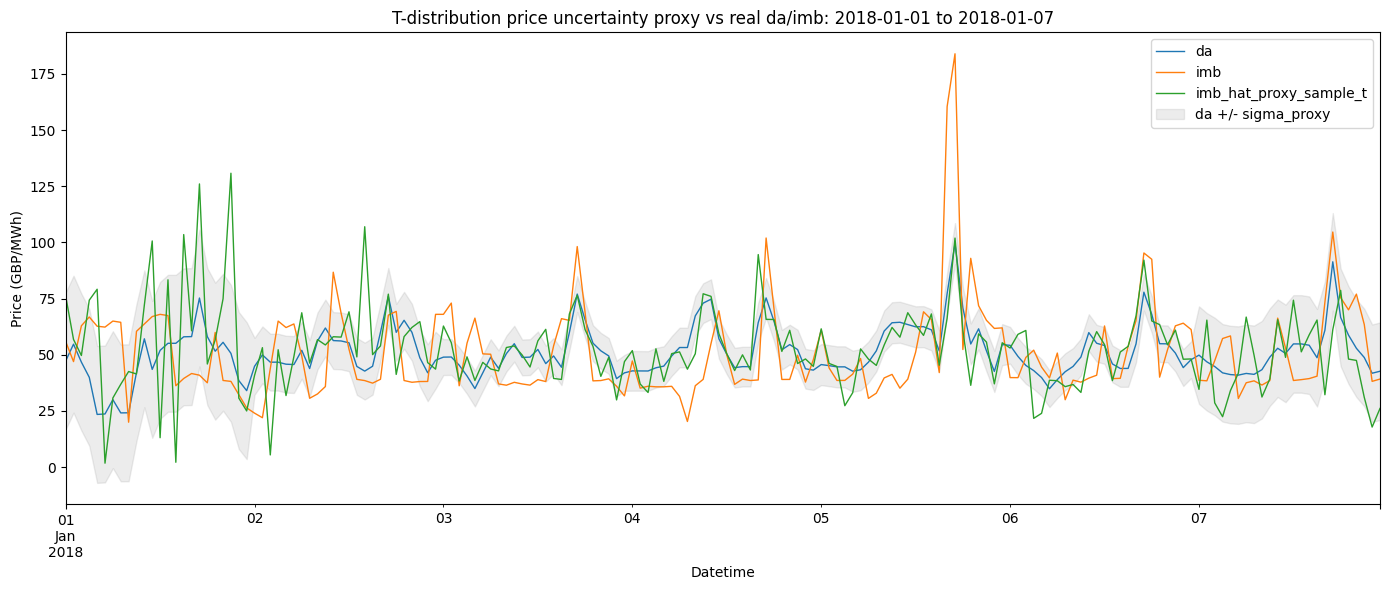

In [ ]:
rng = np.random.default_rng(20240801)

# Fit on clipped TRAINING data.
t_dof, t_loc, t_scale = stats.t.fit(spread_clip)

print(f"fitted Student-t params: df={t_dof:.3f}, loc={t_loc:.3f}, scale={t_scale:.3f}")

# scaling of st.d for t distribution
scale_factor = np.sqrt((t_dof - 2) / t_dof) if t_dof > 2 else t_dof

t_noise_sample = rng.standard_t(df=t_dof, size=len(gb_price_final)) * scale_factor * gb_price_final["imb_sigma_proxy"].to_numpy()

gb_price_final["imb_hat_proxy_sample_t"] = gb_price_final["da"] + t_noise_sample

jan_week_proxy = gb_price_final.loc[week_start:week_end]

fig, ax = plt.subplots(figsize=(14, 6))
jan_week_proxy[["da", "imb", "imb_hat_proxy_sample_t"]].plot(ax=ax, linewidth=1)
ax.fill_between(
    jan_week_proxy.index,
    jan_week_proxy["da"] - jan_week_proxy["imb_sigma_proxy"],
    jan_week_proxy["da"] + jan_week_proxy["imb_sigma_proxy"],
    alpha=0.15, color="gray", label="da +/- sigma_proxy",
)
ax.set_xlabel("Datetime")
ax.set_ylabel("Price (GBP/MWh)")
ax.set_title(f"T-distribution price uncertainty proxy vs real da/imb: {week_start.date()} to {week_end.date()}")
ax.legend(loc="best")
plt.tight_layout()
plt.show()

                             count       mean        std      skew   kurtosis
imb                          24120  45.200720  25.920318  3.033101  49.199056
imb_hat_proxy_sample_normal  24120  45.806539  20.858127  0.559365  17.048512
imb_hat_proxy_sample_t       24120  45.741619  20.818731  1.524509  43.438331


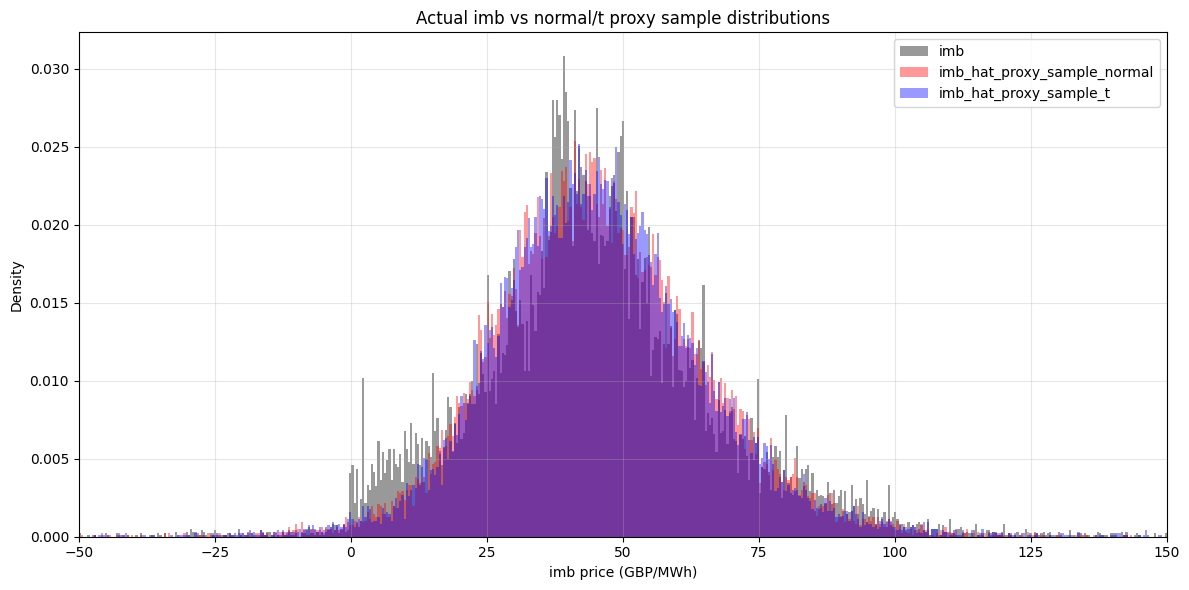

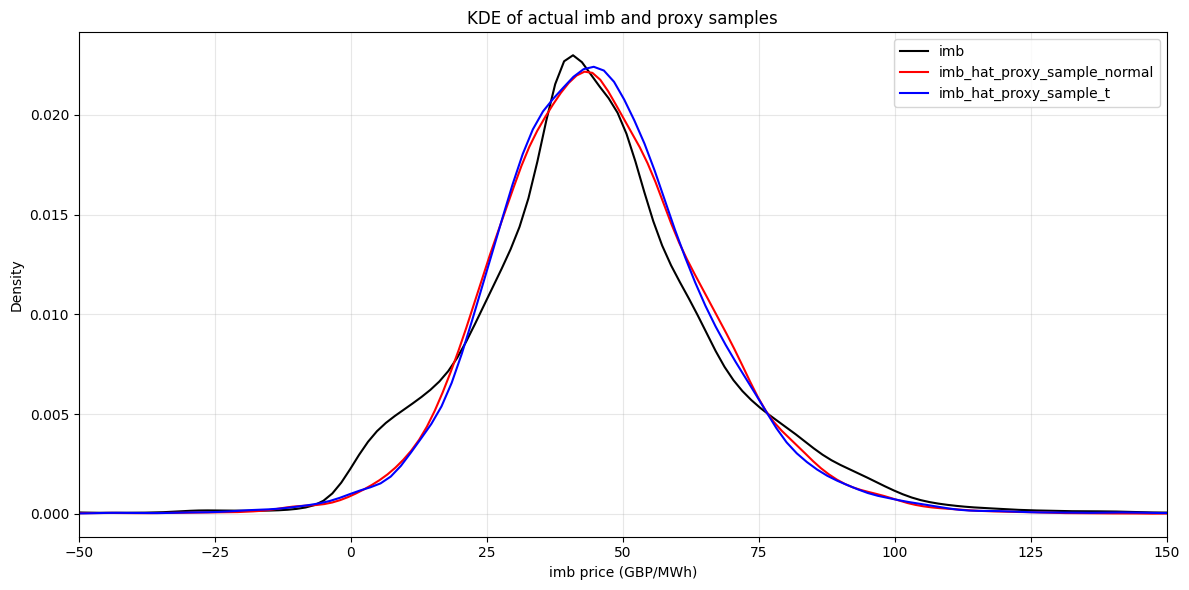

In [ ]:
cols = ["imb", "imb_hat_proxy_sample_normal", "imb_hat_proxy_sample_t"]
compare = gb_price_final[cols].dropna()

summary = pd.DataFrame({
    "count": compare.count(),
    "mean": compare.mean(),
    "std": compare.std(),
    "skew": compare.apply(stats.skew),
    "kurtosis": compare.apply(stats.kurtosis),
})
print(summary)

x_lo, x_hi = -50,150
bins = np.linspace(x_lo, x_hi, 500)

fig, ax = plt.subplots(figsize=(12, 6))
for col, color in zip(cols, ["black", "red", "blue"]):
    ax.hist(compare[col], bins=bins, density=True, alpha=0.4, label=col, color=color)
ax.set_xlim(x_lo, x_hi)
ax.set_xlabel("imb price (GBP/MWh)")
ax.set_ylabel("Density")
ax.set_title("Actual imb vs normal/t proxy sample distributions")
ax.legend(loc="best")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 6))
for col, color in zip(cols, ["black", "red", "blue"]):
    compare[col].plot.kde(ax=ax, label=col, color=color)
ax.set_xlim(x_lo, x_hi)
ax.set_xlabel("imb price (GBP/MWh)")
ax.set_ylabel("Density")
ax.set_title("KDE of actual imb and proxy samples")
ax.legend(loc="best")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## FINALISE

- t-dist proxy, fit on training data has better statistical properties than equivalent standard normal dist. when compared to imbalance entire dataset.
- closer standard deviation, skew and kurtosis.
- However, it is an imperfect proxy. This is fine for this dissertation, as it is not load bearing for the modelling.
- All it needs to do is model imbalance price uncertaint, which it does.
- Therefore, use t-dist as proxy for true imbalance price.

Assumptions made:
- Imbalance price has mean of day-ahead price (roughly true)
- Imbalance price can be represented by t-distribution (roughly true)

Also:
- Clip all price values to floor of 0 (makes modelling simpler).

In [ ]:
gb_price_final.head()

,da,imb,imb_up,imb_down,imb_sigma_proxy,imb_hat_proxy_sample_normal,imb_hat_proxy_sample_t
datetime,,,,,,,
2017-11-01 00:00:00+00:00,43.590699,44.500,44.500000,43.590699,NaN,NaN,NaN
2017-11-01 01:00:00+00:00,40.188327,43.220,43.220000,40.188327,NaN,NaN,NaN
2017-11-01 02:00:00+00:00,32.936364,33.050,33.050000,32.936364,NaN,NaN,NaN
2017-11-01 03:00:00+00:00,30.419661,36.645,36.645000,30.419661,NaN,NaN,NaN
2017-11-01 04:00:00+00:00,29.937366,25.545,29.937366,25.545000,NaN,NaN,NaN


In [ ]:
gb_price_final["imb_fc"] = gb_price_final["imb_hat_proxy_sample_t"]
imb_up_fc = np.maximum(gb_price_final["da"], gb_price_final["imb_fc"])
imb_down_fc = np.minimum(gb_price_final["da"], gb_price_final["imb_fc"])

#gb_price_final["up_reg_cost_fc"] = (imb_up_fc - gb_price_final["da"]).clip(lower=0)
#gb_price_final["down_reg_cost_fc"] = (gb_price_final["da"] - imb_down_fc).clip(lower=0)
gb_price_final["imb_up_fc"] = imb_up_fc
gb_price_final["imb_down_fc"] = imb_down_fc

gb_price_final.tail(5)

,da,imb,imb_up,imb_down,imb_sigma_proxy,imb_hat_proxy_sample_normal,imb_hat_proxy_sample_t,imb_fc,imb_up_fc,imb_down_fc
datetime,,,,,,,,,,
2020-08-03 19:00:00+00:00,38.494320,47.000,47.000000,38.494320,7.875049,46.873961,27.181284,27.181284,38.494320,27.181284
2020-08-03 20:00:00+00:00,37.738824,39.310,39.310000,37.738824,7.875049,24.028561,41.635608,41.635608,41.635608,37.738824
2020-08-03 21:00:00+00:00,32.261478,15.125,32.261478,15.125000,7.875049,27.034724,27.518098,27.518098,32.261478,27.518098
2020-08-03 22:00:00+00:00,29.230500,26.770,29.230500,26.770000,7.875049,26.233420,31.383259,31.383259,31.383259,29.230500
2020-08-03 23:00:00+00:00,25.839762,26.770,26.770000,25.839762,7.875049,33.685733,40.003611,40.003611,40.003611,25.839762


In [ ]:
### clip any values used as inputs to models.

gb_price_final["da_fc"] = gb_price_final["da"].clip(lower = 0)
gb_price_final["imb_fc"] = gb_price_final["imb_fc"].clip(lower = 0)
gb_price_final["imb_up_fc"] = gb_price_final["imb_up_fc"].clip(lower = 0)
gb_price_final["imb_down_fc"] = gb_price_final["imb_down_fc"].clip(lower = 0)

clipped_cols = ["da_fc", "imb_fc", "imb_up_fc", "imb_down_fc"]
assert not (gb_price_final[clipped_cols] < 0).any().any(), "Clipping didn't work"

In [ ]:
# Re-save gb_price.csv now that it includes the _fc columns (the earlier save, cell
# 183cb883, ran before these existed). wpd_comp_processing.ipynb needs to be re-run
# after this to propagate the _fc columns into df_full.csv.
gb_price_final.to_csv(SAVE_DIR / "gb_price.csv", index=True)
print(f"saved {SAVE_DIR / 'gb_price.csv'} with columns: {list(gb_price_final.columns)}")

saved /home/fleet75/diss_bess/1_data/processed/gb_price.csv with columns: ['da', 'imb', 'imb_up', 'imb_down', 'imb_sigma_proxy', 'imb_hat_proxy_sample_normal', 'imb_hat_proxy_sample_t', 'imb_fc', 'imb_up_fc', 'imb_down_fc', 'da_fc']


## Plot values just to see.

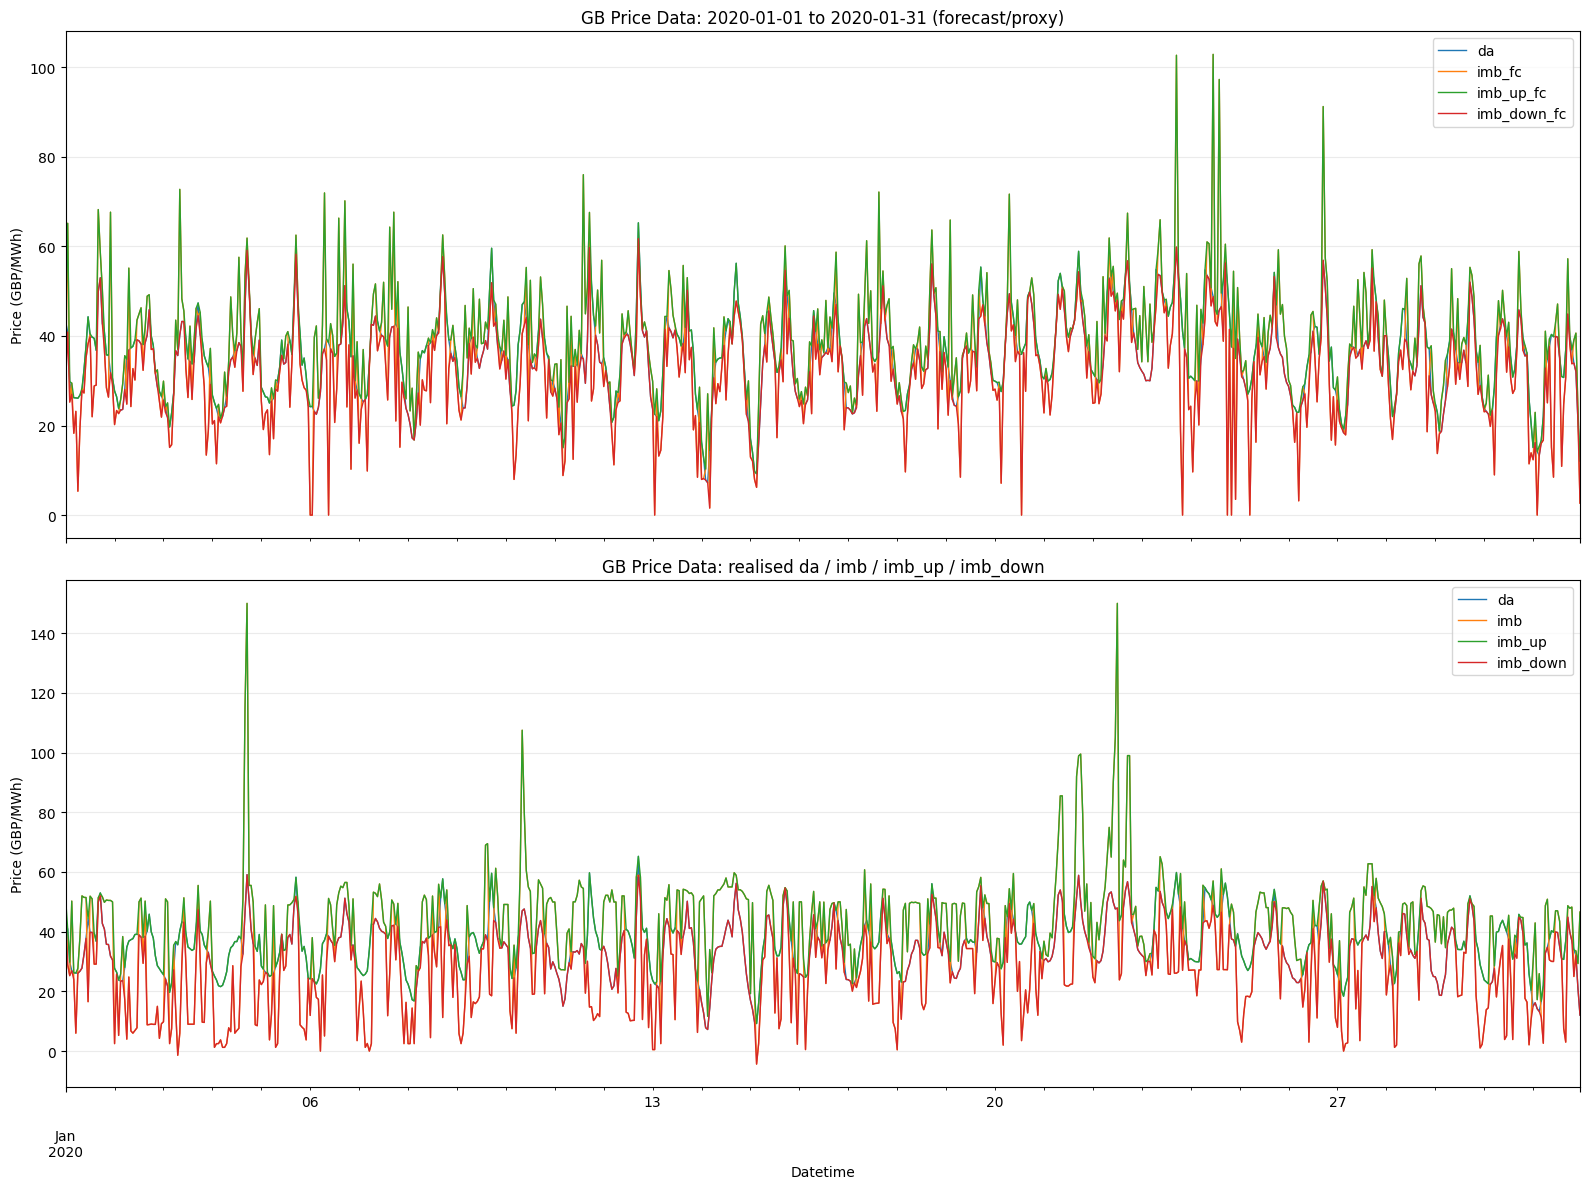

In [ ]:
# Plot one month of 2020 using the forecast/proxy columns that exist in gb_price_final
# (the notebook has "imb_fc", not "imb_fv")
month_start = pd.Timestamp("2020-01-01 00:00:00", tz="UTC")
month_end = pd.Timestamp("2020-01-31 23:00:00", tz="UTC")

jan_2020 = gb_price_final.loc[month_start:month_end]

top_plot_cols = ["da", "imb_fc", "imb_up_fc", "imb_down_fc"]
bottom_plot_cols = ["da", "imb", "imb_up", "imb_down"]

missing_top = [c for c in top_plot_cols if c not in jan_2020.columns]
if missing_top:
    raise KeyError(f"Missing expected columns for top plot: {missing_top}")

missing_bottom = [c for c in bottom_plot_cols if c not in jan_2020.columns]
if missing_bottom:
    raise KeyError(f"Missing expected columns for bottom plot: {missing_bottom}")

fig, (ax_top, ax_bottom) = plt.subplots(
    2, 1, figsize=(16, 12), sharex=True, gridspec_kw={"height_ratios": [1, 1]}
)

jan_2020[top_plot_cols].plot(ax=ax_top, linewidth=1)
ax_top.set_ylabel("Price (GBP/MWh)")
ax_top.set_title(f"GB Price Data: {month_start.date()} to {month_end.date()} (forecast/proxy)")
ax_top.legend(loc="best")
ax_top.grid(alpha=0.25)

jan_2020[bottom_plot_cols].plot(ax=ax_bottom, linewidth=1)
ax_bottom.set_xlabel("Datetime")
ax_bottom.set_ylabel("Price (GBP/MWh)")
ax_bottom.set_title("GB Price Data: realised da / imb / imb_up / imb_down")
ax_bottom.legend(loc="best")
ax_bottom.grid(alpha=0.25)

plt.tight_layout()
plt.show()

In [ ]:
print(gb_price_final["imb"].describe())
print(gb_price_final["imb_fc"].describe())


count    24168.000000
mean        45.212934
std         25.906400
min       -123.404370
25%         31.633750
50%         43.610182
75%         57.045000
max        695.000000
Name: imb, dtype: float64
count    24120.000000
mean        45.921333
std         20.139041
min          0.000000
25%         33.111176
50%         44.824144
75%         57.035090
max        668.328300
Name: imb_fc, dtype: float64


Summary statistics for spread series (including mean_abs)
               count      mean   mean_abs        std    median         min  \
actual_spread  24120  0.494321  14.226846  20.894563  2.005012 -620.063449   
proxy_spread   24120 -0.226292   7.511785  12.107391 -0.042721 -597.913820   

                     max      skew    kurtosis  
actual_spread  232.97765 -3.896698   82.915461  
proxy_spread   112.53472 -6.098784  265.499992  

Paired t-test (actual_spread vs proxy_spread)
t-statistic: 4.643017
p-value: 3.451662e-06

Two-sample KS test (actual_spread vs proxy_spread)
statistic: 0.181633
p-value: 0.000000e+00

Proxy error metrics (proxy_spread - actual_spread)
MAE: 16.3645
RMSE: 24.1143
Mean bias: -0.7206
Mean absolute delta: 16.3645


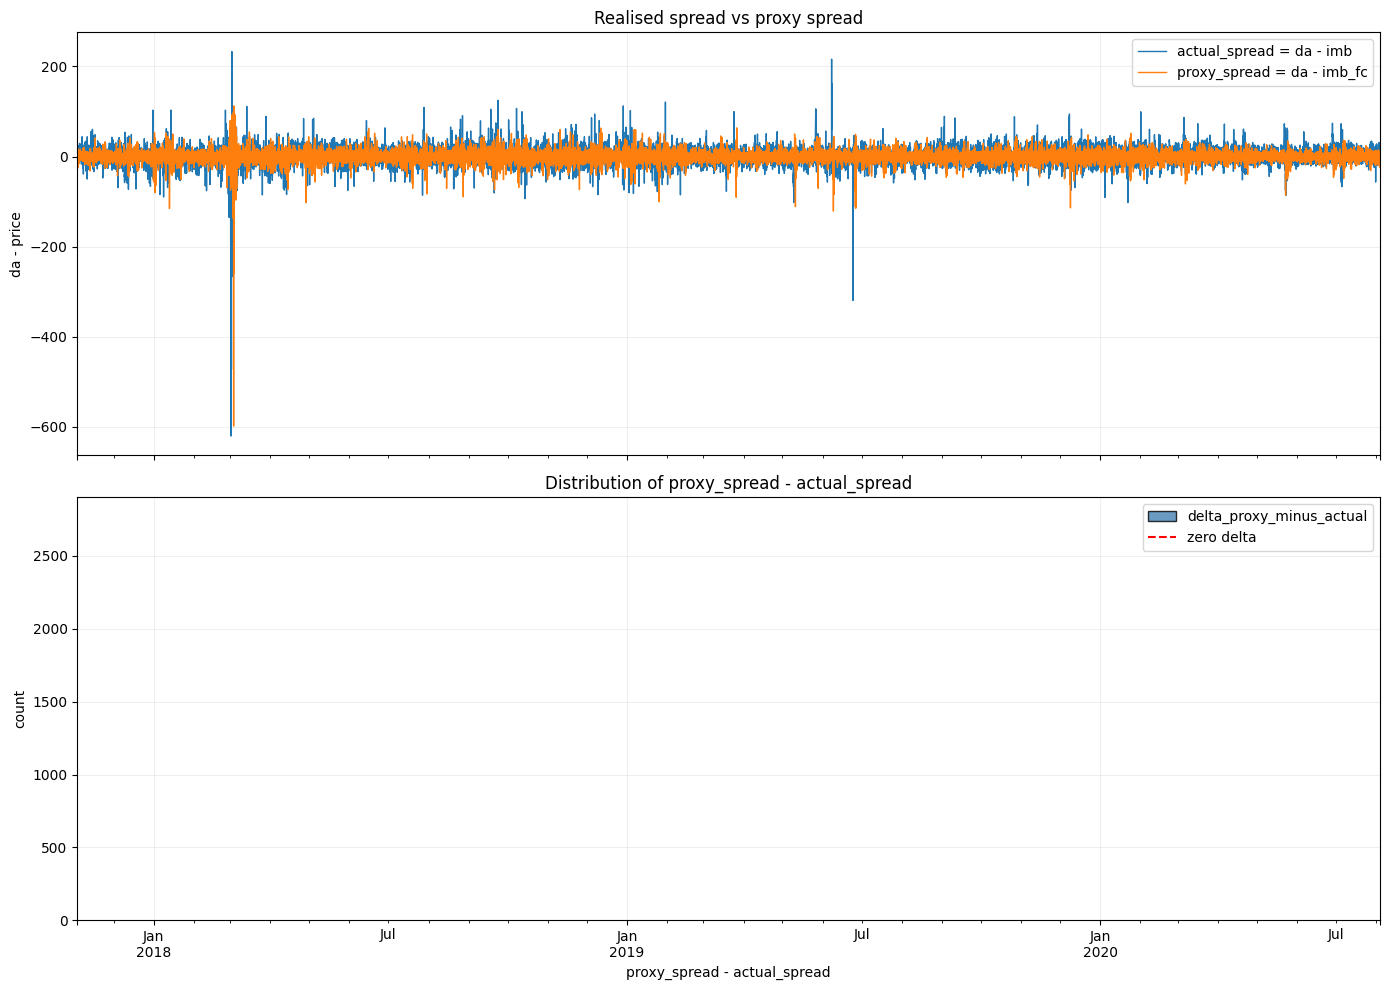

In [ ]:
# Compare realised spread (da - imb) with proxy spread (da - imb_fc) focusing on mean & mean absolute
actual_spread = gb_price_final["da"] - gb_price_final["imb"]
proxy_spread = gb_price_final["da"] - gb_price_final["imb_fc"]

compare = pd.DataFrame({
    "actual_spread": actual_spread,
    "proxy_spread": proxy_spread,
    "delta_proxy_minus_actual": proxy_spread - actual_spread,
}).dropna()

summary = pd.DataFrame({
    "count": compare[["actual_spread", "proxy_spread"]].count(),
    "mean": compare[["actual_spread", "proxy_spread"]].mean(),
    "mean_abs": compare[["actual_spread", "proxy_spread"]].abs().mean(),
    "std": compare[["actual_spread", "proxy_spread"]].std(),
    "median": compare[["actual_spread", "proxy_spread"]].median(),
    "min": compare[["actual_spread", "proxy_spread"]].min(),
    "max": compare[["actual_spread", "proxy_spread"]].max(),
    "skew": compare[["actual_spread", "proxy_spread"]].apply(stats.skew),
    "kurtosis": compare[["actual_spread", "proxy_spread"]].apply(stats.kurtosis),
})
print("Summary statistics for spread series (including mean_abs)")
print(summary)
print()

# Paired tests (dropna to ensure equal-length samples)
a = actual_spread.dropna()
p = proxy_spread.dropna()
common_index = a.index.intersection(p.index)
ttest_rel = stats.ttest_rel(a.loc[common_index], p.loc[common_index])
ks_test = stats.ks_2samp(a.loc[common_index], p.loc[common_index])

print("Paired t-test (actual_spread vs proxy_spread)")
print(f"t-statistic: {ttest_rel.statistic:.6f}")
print(f"p-value: {ttest_rel.pvalue:.6e}")
print()

print("Two-sample KS test (actual_spread vs proxy_spread)")
print(f"statistic: {ks_test.statistic:.6f}")
print(f"p-value: {ks_test.pvalue:.6e}")
print()

# Error metrics for proxy vs actual
delta = compare["delta_proxy_minus_actual"]
mae = delta.abs().mean()
rmse = np.sqrt((delta ** 2).mean())
bias = delta.mean()
mean_abs_delta = delta.abs().mean()
print("Proxy error metrics (proxy_spread - actual_spread)")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"Mean bias: {bias:.4f}")
print(f"Mean absolute delta: {mean_abs_delta:.4f}")

# Quick visual comparison
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

compare[["actual_spread", "proxy_spread"]].plot(ax=axes[0], linewidth=1)
axes[0].set_title("Realised spread vs proxy spread")
axes[0].set_ylabel("da - price")
axes[0].legend(["actual_spread = da - imb", "proxy_spread = da - imb_fc"])
axes[0].grid(alpha=0.2)

delta.plot.hist(bins=200, ax=axes[1], alpha=0.8, color="steelblue", edgecolor="black")
axes[1].axvline(0, color="red", linestyle="--", linewidth=1.5, label="zero delta")
axes[1].set_title("Distribution of proxy_spread - actual_spread")
axes[1].set_xlabel("proxy_spread - actual_spread")
axes[1].set_ylabel("count")
axes[1].legend()
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()